## Step 1: Importing Packages

In [1]:
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, Input
from keras.optimizers import Adam
from keras.callbacks import TensorBoard
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder 
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import itertools
import tensorflow as tf
from keras import backend as K
from keras.layers import Layer
from keras.models import Model


2025-01-31 13:29:34.662589: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738330175.881817    7885 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738330176.141850    7885 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-31 13:29:38.282070: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Step 2: Loading and Inspecting the Dataset

In [2]:
# Load the .npz file
data = np.load('/home/khobby/Desktop/project_code/new_feed02/labeled_faces.npz')

print("Keys in the .npz file:", data.files)

# Inspect the shape and type of the data arrays
for key in data.files:
    print(f"Shape of {key}: {data[key].shape}")
    print(f"Data type of {key}: {data[key].dtype}")

Keys in the .npz file: ['data', 'labels']
Shape of data: (144, 224, 224, 3)
Data type of data: uint8
Shape of labels: (144,)
Data type of labels: int32


## Step 3: Preprocessing the Images

In [3]:
import cv2
import numpy as np

# Function to resize and convert images to grayscale
def preprocess_images(images, target_shape):
    processed_images = []
    for img in images:
        if isinstance(img, np.ndarray) and img.size > 0:  # Check if img is a valid numpy array
            resized_img = cv2.resize(img, (target_shape[1], target_shape[0]))  # Resize image
            gray_img = cv2.cvtColor(resized_img, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
            processed_images.append(gray_img)
        else:
            print("Invalid image found, skipping...")
    return np.array(processed_images)

# Load the data
data = np.loadata = np.load('/home/khobby/Desktop/project_code/new_feed02/labeled_faces.npz')

x = data['data']
y = data['labels']

# Preprocess the images
target_shape = (112, 92)
x_processed = preprocess_images(x, target_shape)

# Check the processed shape
print('Processed x shape:', x_processed.shape)


Processed x shape: (144, 112, 92)


## Save the Preprocessed Data and Labels to NPZ

In [4]:
# Save processed data and labels to NPZ
npz_filename = '/home/khobby/Desktop/project_code/Main/faces_dataset_preprocessed.npz'

np.savez(npz_filename, data=x_processed, labels=y)

# Verify the saved NPZ file
loaded_data = np.load(npz_filename)
x = loaded_data['data']
y = loaded_data['labels']
print("Keys in NPZ file:", loaded_data.keys())
print("Shape of data in NPZ file:", x.shape)
print("Shape of labels in NPZ file:", y.shape)


Keys in NPZ file: KeysView(NpzFile '/home/khobby/Desktop/project_code/Main/faces_dataset_preprocessed.npz' with keys: data, labels)
Shape of data in NPZ file: (144, 112, 92)
Shape of labels in NPZ file: (144,)


## Load Data and Split into Training and Validation Sets

In [6]:
# Split the data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x_processed, y, test_size=0.2, random_state=42)

# Optionally split a validation set from the training data
x_train, x_valid, y_train, y_valid = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# Normalize the images
x_train = np.array(x_train, dtype='float32') / 255
x_valid = np.array(x_valid, dtype='float32') / 255
x_test = np.array(x_test, dtype='float32') / 255

# Reshape the data
x_train = x_train.reshape(x_train.shape[0], 112, 92, 1)
x_valid = x_valid.reshape(x_valid.shape[0], 112, 92, 1)
x_test = x_test.reshape(x_test.shape[0], 112, 92, 1)

# Show the final shapes
print('x_train shape:', x_train.shape)
print('x_valid shape:', x_valid.shape)
print('x_test shape:', x_test.shape)
print('y_train shape:', y_train.shape)
print('y_valid shape:', y_valid.shape)
print('y_test shape:', y_test.shape)

# Save the processed data into a new .npz file
np.savez('processed_data.npz', trainX=x_train, validX=x_valid, testX=x_test, trainY=y_train, validY=y_valid, testY=y_test)


x_train shape: (92, 112, 92, 1)
x_valid shape: (23, 112, 92, 1)
x_test shape: (29, 112, 92, 1)
y_train shape: (92,)
y_valid shape: (23,)
y_test shape: (29,)


## Define and Train the CNN Model

In [7]:

# Load the processed data
data = np.load('processed_data.npz')
x_train = data['trainX']
x_valid = data['validX']
x_test = data['testX']
y_train = data['trainY']
y_valid = data['validY']
y_test = data['testY']

# Encode string labels to integers
label_encoder = LabelEncoder()
y_train_int = label_encoder.fit_transform(y_train)
y_valid_int = label_encoder.transform(y_valid)
y_test_int = label_encoder.transform(y_test)

# Convert integer labels to categorical
num_classes = len(np.unique(y_train_int))
y_train_cat = keras.utils.to_categorical(y_train_int, num_classes)
y_valid_cat = keras.utils.to_categorical(y_valid_int, num_classes)
y_test_cat = keras.utils.to_categorical(y_test_int, num_classes)

# Input layer
input_layer = Input(shape=(112, 92, 1))

# Build the CNN model
x = Conv2D(32, kernel_size=(3, 3), activation='relu')(input_layer)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Conv2D(64, kernel_size=(3, 3), activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Conv2D(128, kernel_size=(3, 3), activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Conv2D(256, kernel_size=(3, 3), activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Flatten()(x)
features = Dense(128, activation='relu')(x)
dropout = Dropout(0.5)(features)
outputs = Dense(num_classes, activation='softmax')(dropout)

# Combine the two outputs
model = Model(inputs=input_layer, outputs=outputs)

# Compile the model with a lower learning rate
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Model summary
model.summary()


2025-01-31 13:31:22.744537: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 112, 92, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 110, 90, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 55, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 53, 43, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 26, 21, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 19, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 9, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 7, 256)     │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3840)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       491,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 882,842 (3.37 MB)

 Trainable params: 882,842 (3.37 MB)

 Non-trainable params: 0 (0.00 B)

##  Train the Model

In [ ]:
from keras.callbacks import EarlyStopping

# Define the early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',     # Monitor the validation loss
    patience=10,             # Number of epochs with no improvement after which training will be stopped
    verbose=1,              # Verbosity mode
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)

# Train the model with early stopping
history = model.fit(
    x_train, y_train_cat,
    batch_size=32,
    epochs=50,
    validation_data=(x_valid, y_valid_cat),
    verbose=1,
    callbacks=[early_stopping]
)

# Evaluate the model
score = model.evaluate(x_test, y_test_cat, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])


# Plot the accuracy and loss curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()



Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 454ms/step - accuracy: 0.0319 - loss: 3.2633 - val_accuracy: 0.0435 - val_loss: 3.2604
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 374ms/step - accuracy: 0.0530 - loss: 3.2463 - val_accuracy: 0.0435 - val_loss: 3.2792
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 363ms/step - accuracy: 0.0413 - loss: 3.2316 - val_accuracy: 0.0000e+00 - val_loss: 3.3362
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 345ms/step - accuracy: 0.0343 - loss: 3.2809 - val_accuracy: 0.0000e+00 - val_loss: 3.3022
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 344ms/step - accuracy: 0.0708 - loss: 3.2192 - val_accuracy: 0.0435 - val_loss: 3.2850
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 402ms/step - accuracy: 0.0717 - loss: 3.1983 - val_accuracy: 0.0870 - val_loss: 3.3095
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 402ms/step - accuracy: 0.0350 - loss: 3.1788 - val_accuracy: 0.1304 - val_loss: 3.3553
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 401ms/step - accuracy: 0.0864 - loss: 3.1729 - val_accuracy: 0.1304 - v

##  classification report

In [9]:
plt.show()
# Predict on test data
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_cat, axis=1)
valid_labels = np.argmax(y_test_cat, axis=1)  

# Correct target names
valid_label_classes = label_encoder.classes_[label_encoder.transform(valid_labels)]

# Print classification report
print('Classification Report')
print(classification_report(y_true, y_pred_classes))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         5
           6       1.00      0.50      0.67         2
           7       1.00      1.00      1.00         1
           8       0.67      1.00      0.80         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         1
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         1
          15       1.00      1.00      1.00         1
          16       1.00      1.00      1.00         1
          17       1.00      1.00      1.00         1
          18       1.

## Confusion Matrix

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step 
Confusion matrix, without normalization
[[5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1

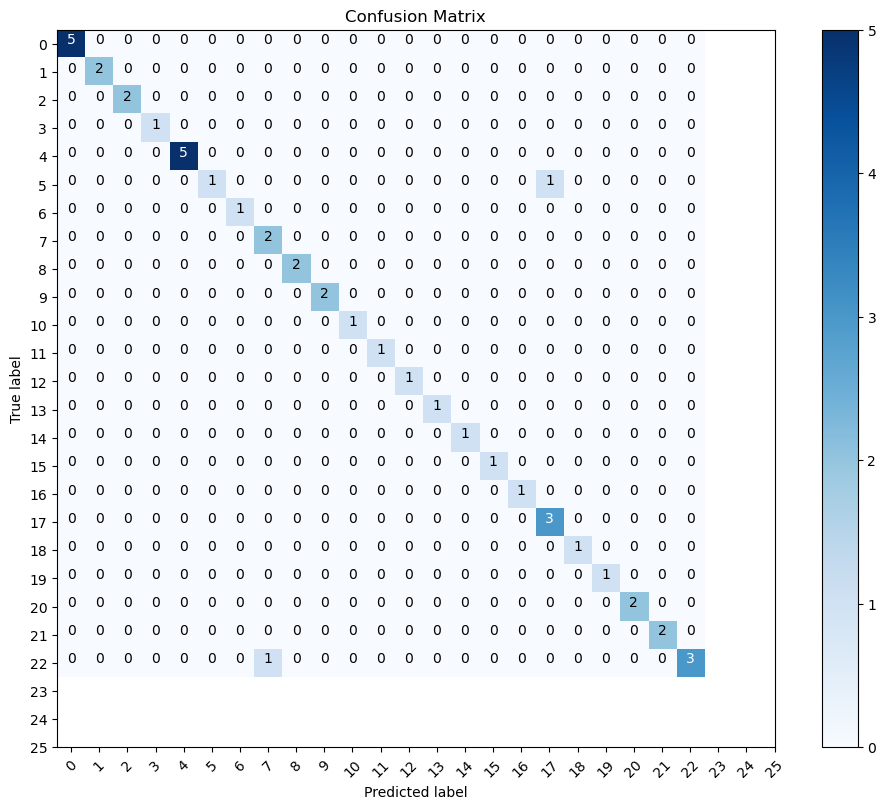

In [10]:
# Predict on test data
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# Compute confusion matrix
from sklearn.metrics import confusion_matrix
import itertools

confusion_mtx = confusion_matrix(y_true, y_pred_classes)

# Function to plot the confusion matrix
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(10, 8))  # Increase the figure size for better readability
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print("Confusion matrix, without normalization")

    print(cm)

    thresh = cm.max() / 2.
    fmt = '.2f' if normalize else 'd'
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Plot non-normalized confusion matrix
plot_confusion_matrix(confusion_mtx, classes=label_encoder.classes_, normalize=False, title='Confusion Matrix')
plt.show()


## Saving the Model

In [11]:
# Save the model using the recommended Keras format
model.save('face_recognition_model.keras')


In [ ]:

import cv2
import numpy as np
import dlib
from keras.models import load_model
from sklearn.metrics.pairwise import cosine_similarity

# Load the Keras model (if you have a specific trained model for face recognition)
model = load_model('face_recognition_model.keras')

# Load the dlib face detector and face recognition models
detector = dlib.get_frontal_face_detector()
sp = dlib.shape_predictor('/home/khobby/Desktop/project_code/Predictor/shape_predictor_68_face_landmarks.dat')
facerec = dlib.face_recognition_model_v1('/home/khobby/Desktop/project_code/Predictor/dlib_face_recognition_resnet_model_v1.dat')

# Function to preprocess a single face image for the Keras model
def preprocess_face_image(image, target_shape=(112, 92)):
    resized_img = cv2.resize(image, (target_shape[1], target_shape[0]))
    gray_img = cv2.cvtColor(resized_img, cv2.COLOR_BGR2GRAY)
    return gray_img.reshape(1, 112, 92, 1)

# Function to draw bounding boxes and labels on the frame
def draw_bounding_boxes(frame, face_locations, face_labels):
    for (top, right, bottom, left), label in zip(face_locations, face_labels):
        cv2.rectangle(frame, (left, top), (right, bottom), (0, 255, 0), 2)
        cv2.putText(frame, str(label), (left, top - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

# Function to extract face embeddings using dlib
def extract_face_embeddings_dlib(image, box):
    (startX, startY, endX, endY) = box
    rect = dlib.rectangle(int(startX), int(startY), int(endX), int(endY))
    shape = sp(image, rect)
    face_embedding = np.array(facerec.compute_face_descriptor(image, shape))
    return face_embedding

# Function to calculate cosine similarity
def calculate_similarity(embedding1, embedding2):
    return cosine_similarity(embedding1.reshape(1, -1), embedding2.reshape(1, -1))[0][0]

# Load the video
video_path = r"C:\Users\Raymond\Desktop\Maxwell_code\finVid.mp4"
cap = cv2.VideoCapture(video_path)

# Initialize video writer
output_path = r"C:\Users\Raymond\Desktop\Maxwell_code\output5.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# Dictionary to store known faces and their embeddings
known_faces = {}
next_id = 1  # Initialize the unique ID counter

# Process the video frame by frame
while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    (h, w) = frame.shape[:2]
    
    # Convert the frame to grayscale
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    # Detect faces in the frame using dlib
    dets = detector(gray_frame, 1)
    
    face_locations = []
    face_labels = []
    
    for i, rect in enumerate(dets):
        (startX, startY, endX, endY) = (rect.left(), rect.top(), rect.right(), rect.bottom())
        face = frame[startY:endY, startX:endX]
        
        # Preprocess the face for Keras model prediction
        preprocessed_face = preprocess_face_image(face)
        prediction = model.predict(preprocessed_face)
        predicted_class = np.argmax(prediction, axis=1)
        
        # Get dlib face embeddings for the detected face
        face_embedding = extract_face_embeddings_dlib(frame, (startX, startY, endX, endY))
        
        match_found = False
        label = None
        
        # Compare this embedding to all known faces
        for id, known_embedding in known_faces.items():
            similarity = calculate_similarity(face_embedding, known_embedding)
            if similarity > 0.6:  # Threshold for considering a match
                label = f"ID {id}"
                match_found = True
                break
        
        if not match_found:
            # Assign a new ID if no match is found
            label = f"ID {next_id}"
            known_faces[next_id] = face_embedding
            next_id += 1
        
        # Add the bounding box and label
        face_locations.append((startY, endX, endY, startX))
        face_labels.append(label)
    
    # Draw bounding boxes and labels on the frame
    draw_bounding_boxes(frame, face_locations, face_labels)
    
    # Write the frame with bounding boxes to the output video
    out.write(frame)
    
    # Display the frame (optional)
    cv2.imshow('Video', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
out.release()
cv2.destroyAllWindows()


## Another testing model

In [ ]:
import cv2
import numpy as np
import dlib
from keras.models import load_model
from sklearn.metrics.pairwise import cosine_similarity

# Load the Keras model (if you have a specific trained model for face recognition)
model = load_model('face_recognition_model.keras')

# Load the dlib face detector and face recognition models
detector = dlib.get_frontal_face_detector()
sp = dlib.shape_predictor(r"C:\Users\Raymond\Desktop\pj1\TMdel\shape_predictor_68_face_landmarks.dat")
facerec = dlib.face_recognition_model_v1(r"C:\Users\Raymond\Desktop\pj1\TMdel\dlib_face_recognition_resnet_model_v1.dat")

# Function to preprocess a single face image for the Keras model
def preprocess_face_image(image, target_shape=(112, 92)):
    resized_img = cv2.resize(image, (target_shape[1], target_shape[0]))
    gray_img = cv2.cvtColor(resized_img, cv2.COLOR_BGR2GRAY)
    return gray_img.reshape(1, 112, 92, 1)

# Function to draw bounding boxes and labels on the frame
def draw_bounding_boxes(frame, face_locations, face_labels):
    for (top, right, bottom, left), label in zip(face_locations, face_labels):
        cv2.rectangle(frame, (left, top), (right, bottom), (0, 255, 0), 2)
        cv2.putText(frame, str(label), (left, top - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

# Function to extract face embeddings using dlib
def extract_face_embeddings_dlib(image, box):
    (startX, startY, endX, endY) = box
    rect = dlib.rectangle(int(startX), int(startY), int(endX), int(endY))
    shape = sp(image, rect)
    face_embedding = np.array(facerec.compute_face_descriptor(image, shape))
    return face_embedding

# Function to calculate cosine similarity
def calculate_similarity(embedding1, embedding2):
    return cosine_similarity(embedding1.reshape(1, -1), embedding2.reshape(1, -1))[0][0]

# Load the video
video_path = r"C:\Users\Raymond\Desktop\Maxwell_code\finVid.mp4"
cap = cv2.VideoCapture(video_path)

# Initialize video writer
output_path = r"C:\Users\Raymond\Desktop\Maxwell_code\output5.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# Dictionary to store known faces and their embeddings
known_faces = {}
next_id = 1  # Initialize the unique ID counter

# Process the video frame by frame
while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    (h, w) = frame.shape[:2]
    
    # Convert the frame to grayscale
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    # Detect faces in the frame using dlib
    dets = detector(gray_frame, 1)
    
    face_locations = []
    face_labels = []
    
    for i, rect in enumerate(dets):
        (startX, startY, endX, endY) = (rect.left(), rect.top(), rect.right(), rect.bottom())
        face = frame[startY:endY, startX:endX]
        
        # Preprocess the face for Keras model prediction
        preprocessed_face = preprocess_face_image(face)
        prediction = model.predict(preprocessed_face)
        predicted_class = np.argmax(prediction, axis=1)
        
        # Get dlib face embeddings for the detected face
        face_embedding = extract_face_embeddings_dlib(frame, (startX, startY, endX, endY))
        
        match_found = False
        label = None
        
        # Compare this embedding to all known faces
        for id, known_embedding in known_faces.items():
            similarity = calculate_similarity(face_embedding, known_embedding)
            if similarity > 0.6:  # Threshold for considering a match
                label = f"std{id:02d}"
                match_found = True
                break
        
        if not match_found:
            # Assign a new ID if no match is found
            label = f"std{next_id:02d}"
            known_faces[next_id] = face_embedding
            next_id += 1
        
        # Add the bounding box and label
        face_locations.append((startY, endX, endY, startX))
        face_labels.append(label)
    
    # Draw bounding boxes and labels on the frame
    draw_bounding_boxes(frame, face_locations, face_labels)
    
    # Write the frame with bounding boxes to the output video
    out.write(frame)
    
    # Display the frame (optional)
    cv2.imshow('Video', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
out.release()
cv2.destroyAllWindows()


## ANother Video Testing

In [ ]:
import cv2
import numpy as np
import dlib
from keras.models import load_model
from sklearn.metrics.pairwise import cosine_similarity
import random

# Load the Keras model (if you have a specific trained model for face recognition)
model = load_model('face_recognition_model.keras')

# Load the dlib face detector and face recognition models
detector = dlib.get_frontal_face_detector()
sp = dlib.shape_predictor(r"C:\Users\Raymond\Desktop\pj1\TMdel\shape_predictor_68_face_landmarks.dat")
facerec = dlib.face_recognition_model_v1(r"C:\Users\Raymond\Desktop\pj1\TMdel\dlib_face_recognition_resnet_model_v1.dat")

# Function to preprocess a single face image for the Keras model
def preprocess_face_image(image, target_shape=(112, 92)):
    resized_img = cv2.resize(image, (target_shape[1], target_shape[0]))
    gray_img = cv2.cvtColor(resized_img, cv2.COLOR_BGR2GRAY)
    return gray_img.reshape(1, 112, 92, 1)

# Function to draw bounding boxes and labels on the frame
def draw_bounding_boxes(frame, face_locations, face_labels):
    for (top, right, bottom, left), label in zip(face_locations, face_labels):
        cv2.rectangle(frame, (left, top), (right, bottom), (0, 255, 0), 2)
        cv2.putText(frame, str(label), (left, top - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

# Function to extract face embeddings using dlib
def extract_face_embeddings_dlib(image, box):
    (startX, startY, endX, endY) = box
    rect = dlib.rectangle(int(startX), int(startY), int(endX), int(endY))
    shape = sp(image, rect)
    face_embedding = np.array(facerec.compute_face_descriptor(image, shape))
    return face_embedding

# Load the video
video_path = r"C:\Users\Raymond\Desktop\Maxwell_code\finVid.mp4"
cap = cv2.VideoCapture(video_path)

# Initialize video writer
output_path = r"C:\Users\Raymond\Desktop\Maxwell_code\output5.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# Process the video frame by frame
while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    (h, w) = frame.shape[:2]
    
    # Convert the frame to grayscale
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    # Detect faces in the frame using dlib
    dets = detector(gray_frame, 1)
    
    face_locations = []
    face_labels = []
    
    for i, rect in enumerate(dets):
        (startX, startY, endX, endY) = (rect.left(), rect.top(), rect.right(), rect.bottom())
        face = frame[startY:endY, startX:endX]
        
        # Preprocess the face for Keras model prediction
        preprocessed_face = preprocess_face_image(face)
        prediction = model.predict(preprocessed_face)
        predicted_class = np.argmax(prediction, axis=1)
        
        # Generate a random label number for each face
        random_label = random.randint(1, 50)
        label = f"ID{random_label}"
        
        # Add the bounding box and label
        face_locations.append((startY, endX, endY, startX))
        face_labels.append(label)
    
    # Draw bounding boxes and labels on the frame
    draw_bounding_boxes(frame, face_locations, face_labels)
    
    # Write the frame with bounding boxes to the output video
    out.write(frame)
    
    # Display the frame (optional)
    cv2.imshow('Video', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
out.release()
cv2.destroyAllWindows()


In [ ]:
import cv2
import numpy as np
from deepface import DeepFace
import dlib

# Load the dlib face detector
detector = dlib.get_frontal_face_detector()

# Initialize video capture
video_path = r"C:\Users\Raymond\Desktop\Maxwell_code\finVid.mp4"
cap = cv2.VideoCapture(video_path)

# Initialize video writer
output_path = r"C:\Users\Raymond\Desktop\Maxwell_code\output9.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# Dictionary to store known faces and their embeddings
known_faces = {}
next_id = 1  # Initialize the unique ID counter

# Process the video frame by frame
while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    # Convert the frame to grayscale for face detection
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    # Detect faces in the frame using dlib
    dets = detector(gray_frame, 1)
    
    face_locations = []
    face_labels = []
    
    for rect in dets:
        (startX, startY, endX, endY) = (rect.left(), rect.top(), rect.right(), rect.bottom())
        face = frame[startY:endY, startX:endX]
        
        try:
            # Analyze the face to get embeddings using DeepFace (Facenet by default)
            face_embedding = DeepFace.represent(face, model_name="Facenet")[0]['embedding']
        except Exception as e:
            print(f"Error processing face: {e}")
            continue
        
        match_found = False
        label = None
        
        # Compare this embedding to all known faces
        for id, known_embedding in known_faces.items():
            similarity = np.dot(face_embedding, known_embedding) / (np.linalg.norm(face_embedding) * np.linalg.norm(known_embedding))
            if similarity > 0.8:  # Adjust threshold based on your needs
                label = f"ID {id}"
                match_found = True
                break
        
        if not match_found:
            # Assign a new ID if no match is found
            label = f"ID {next_id}"
            known_faces[next_id] = face_embedding
            next_id += 1
        
        # Add the bounding box and label
        face_locations.append((startY, endX, endY, startX))
        face_labels.append(label)
    
    # Draw bounding boxes and labels on the frame
    for (top, right, bottom, left), label in zip(face_locations, face_labels):
        cv2.rectangle(frame, (left, top), (right, bottom), (0, 255, 0), 2)
        cv2.putText(frame, label, (left, top - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
    
    # Write the frame with bounding boxes to the output video
    out.write(frame)
    
    # Display the frame (optional)
    cv2.imshow('Video', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
out.release()
cv2.destroyAllWindows()


In [ ]:
pip install tf-keras
